# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Rayhan Lutfi Hakim | 5054251043 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [37]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [38]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")
print("deskripsi",df.describe())
print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:", df.dtypes)
print("\nJumlah missing value:", df.isnull().sum())

deskripsi          Bankrupt?   ROA(C) before interest and depreciation before interest  \
count  6819.000000                                        6819.000000          
mean      0.032263                                           0.505180          
std       0.176710                                           0.060686          
min       0.000000                                           0.000000          
25%       0.000000                                           0.476527          
50%       0.000000                                           0.502706          
75%       0.000000                                           0.535563          
max       1.000000                                           1.000000          

        ROA(A) before interest and % after tax  \
count                              6819.000000   
mean                                  0.558625   
std                                   0.065620   
min                                   0.000000   
25%                

Distribusi Target (Bankrupt?):
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Persentase:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


C:\Users\M S I\AppData\Local\Temp\ipykernel_22696\4138514752.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


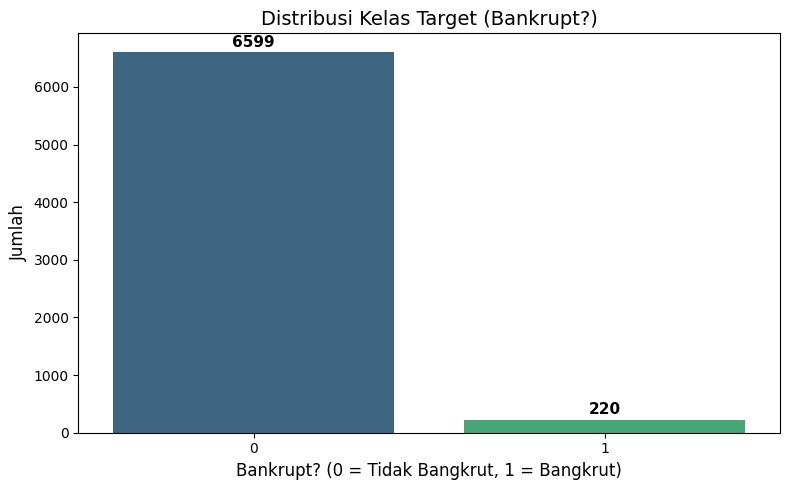

In [39]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_col = 'Bankrupt?'
class_counts = df[target_col].value_counts()
print("Distribusi Target (Bankrupt?):")
print(class_counts)
print("\nPersentase:")
print(df[target_col].value_counts(normalize=True) * 100)
# Membuat Bar Plot
plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title('Distribusi Kelas Target (Bankrupt?)', fontsize=14)
plt.xlabel('Bankrupt? (0 = Tidak Bangkrut, 1 = Bangkrut)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
# Menambahkan label angka di atas bar
for i, count in enumerate(class_counts):
    plt.text(i, count + 100, str(count), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()

plt.show()

6 Fitur dengan korelasi terkuat terhadap Bankrupt?:
Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Debt ratio %                                               0.250161
Name: Bankrupt?, dtype: float64
--------------------------------------------------


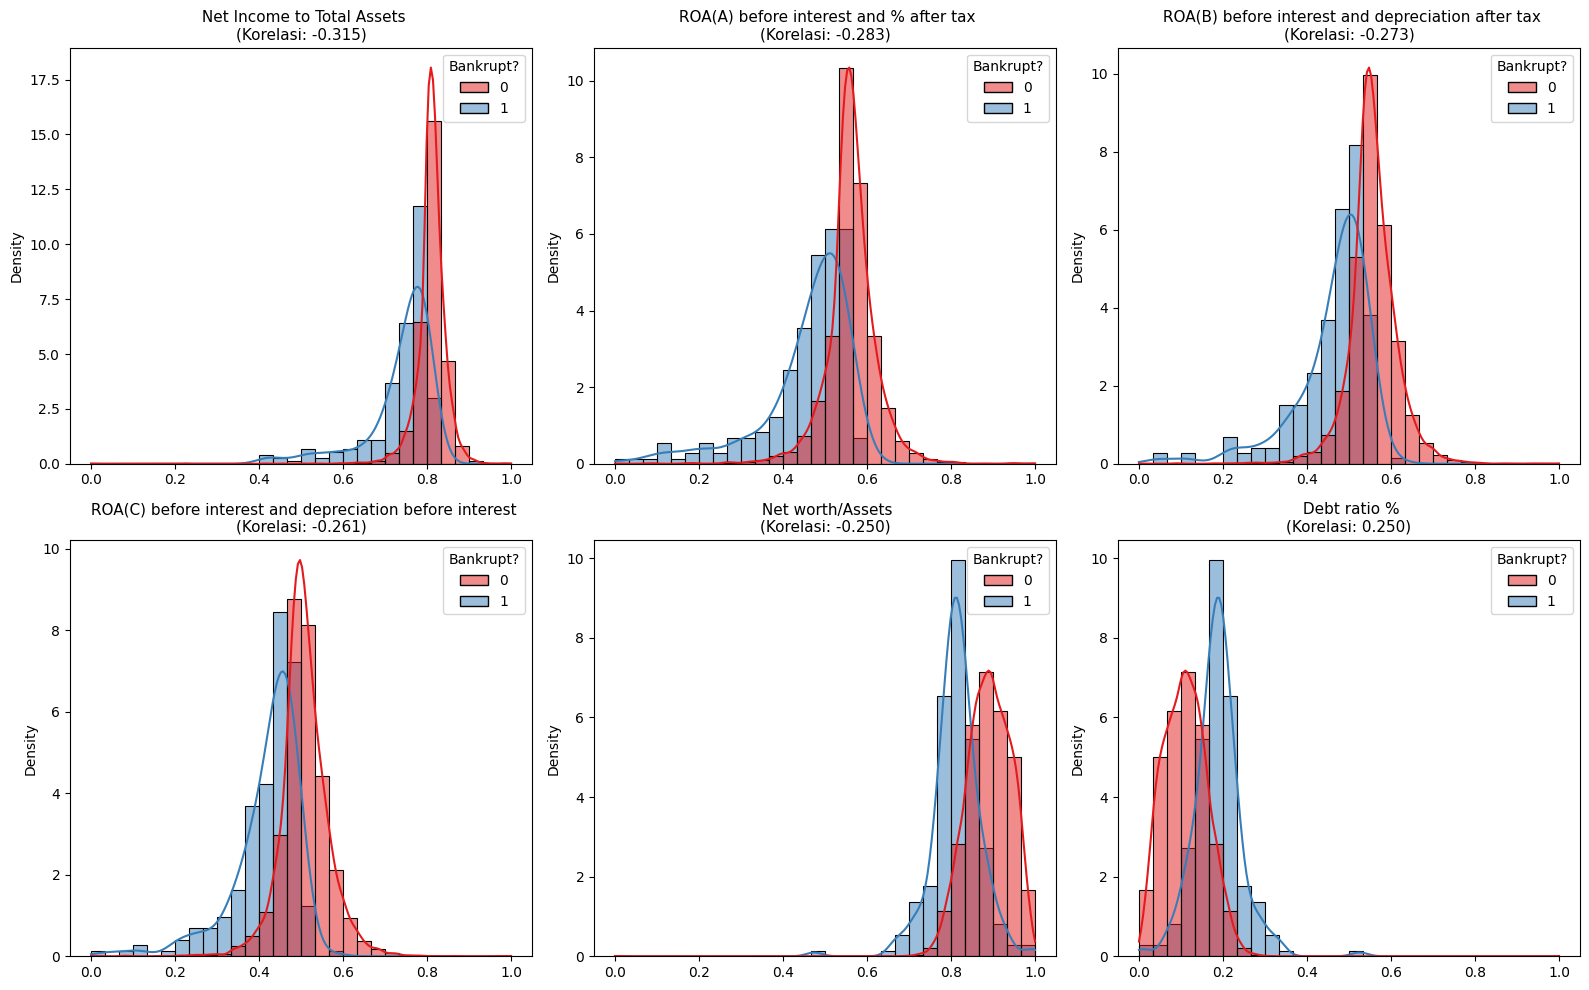

In [40]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
target_col = 'Bankrupt?'
correlations = df.corr()[target_col]
top_features = correlations.drop(target_col).abs().sort_values(ascending=False).head(6).index.tolist()
print("6 Fitur dengan korelasi terkuat terhadap Bankrupt?:")
print(correlations[top_features])
print("-" * 50)

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue=target_col, kde=True, stat="density", 
                 common_norm=False, bins=30, palette='Set1', alpha=0.5)
    plt.title(f"{col}\n(Korelasi: {correlations[col]:.3f})", fontsize=11)
    plt.xlabel('')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [41]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [42]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

In [43]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran Dataset Asli:")
print("X:", X.shape, "| y:", y.shape)
print("\nUkuran Data Setelah Dipecah:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

print("\nProporsi kelas pada y_train:")
print(y_train.value_counts(normalize=True))
print("\nProporsi kelas pada y_test:")
print(y_test.value_counts(normalize=True))

Ukuran Dataset Asli:
X: (6819, 95) | y: (6819,)

Ukuran Data Setelah Dipecah:
X_train: (5455, 95) | y_train: (5455,)
X_test : (1364, 95) | y_test : (1364,)

Proporsi kelas pada y_train:
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Proporsi kelas pada y_test:
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [44]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [45]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)

print("Prediksi Model (10 data pertama):", y_pred_gini[:10])
print("Label Asli (10 data pertama):    ", y_test[:10].values)

Prediksi Model (10 data pertama): [0 0 0 0 0 1 0 0 0 0]
Label Asli (10 data pertama):     [0 0 0 0 0 0 0 0 0 0]


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [46]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [47]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.\
y_pred_entropy = dt_entropy.predict(X_test)
print("Prediksi Model Entropy (10 data pertama):", y_pred_entropy[:10])
print("Label Asli (10 data pertama):            ", y_test[:10].values)

Prediksi Model Entropy (10 data pertama): [0 0 0 0 0 0 0 0 0 0]
Label Asli (10 data pertama):             [0 0 0 0 0 0 0 0 0 0]


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [48]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depths = [1, 2, 3, 5, 10, None]
# List untuk menyimpan model-model yang sudah dilatih
trained_models = []
for depth in depths:
    # Menggunakan kriteria terbaik (Entropy) dan variasi max_depth
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    
    # Melatih model
    model.fit(X_train, y_train)
    
    # Menyimpan model yang sudah dilatih ke dalam list
    trained_models.append(model)

In [49]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_accuracies = []
test_accuracies = []
# Menggunakan trained_models dari cell sebelumnya
for model in trained_models:
    # Menghitung akurasi pada train set
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    train_accuracies.append(acc_train)
    
    # Menghitung akurasi pada test set
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    test_accuracies.append(acc_test)

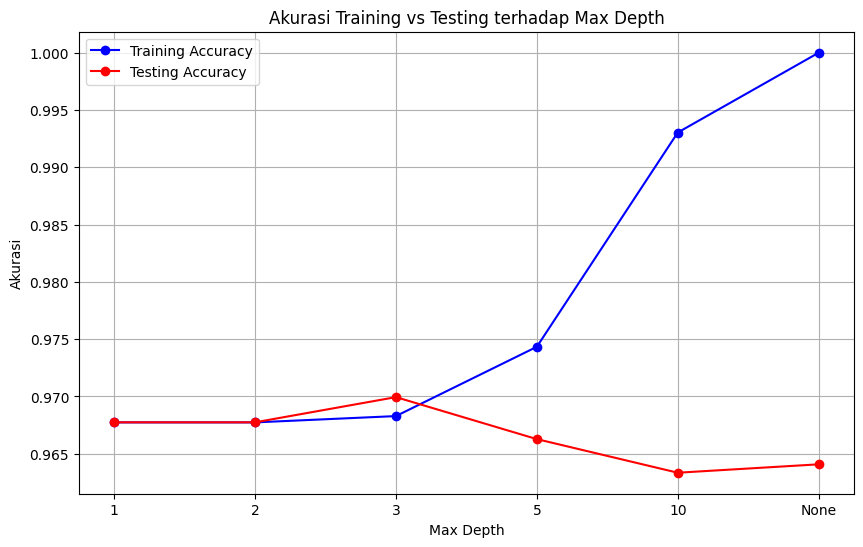

In [50]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
depth_labels = [str(d) if d is not None else "None" for d in depths]
# Plot grafik akurasi training vs testing
plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(depth_labels, test_accuracies, label='Testing Accuracy', marker='o', color='red')
plt.title('Akurasi Training vs Testing terhadap Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [51]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro'),
        f1_score(y_true, y_pred, average='macro')
    ]
# Membuat tabel perbandingan dengan DataFrame
eval_table = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Model Gini': get_metrics(y_test, y_pred_gini),
    'Model Entropy': get_metrics(y_test, y_pred_entropy)
})
display(eval_table)

,Metrik Evaluasi,Model Gini,Model Entropy
0,Accuracy,0.961144,0.964076
1,Precision (Macro),0.690144,0.707760
2,Recall (Macro),0.694318,0.684848
3,F1-Score (Macro),0.692206,0.695557


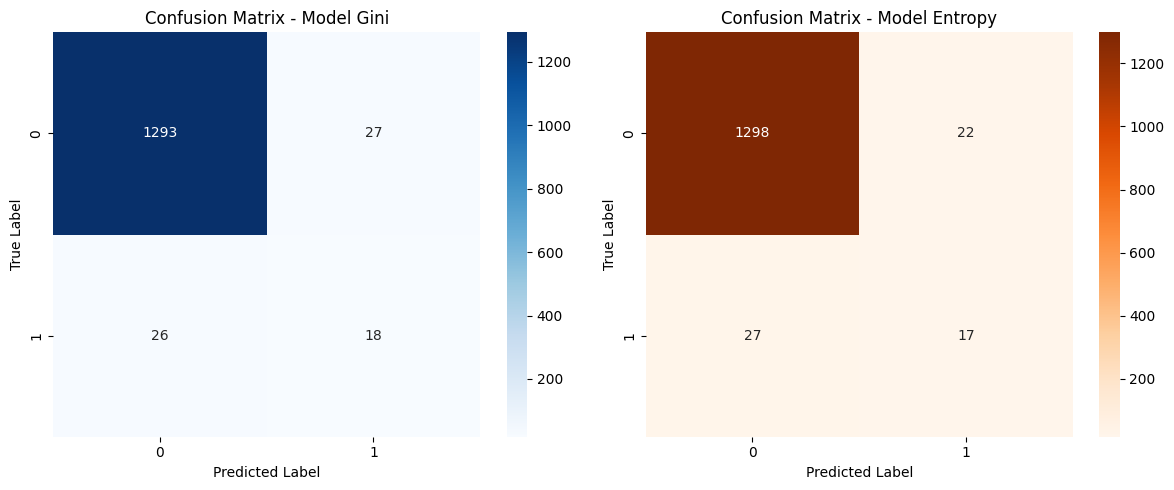

In [52]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Heatmap Gini
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Model Gini')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
# Heatmap Entropy
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - Model Entropy')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

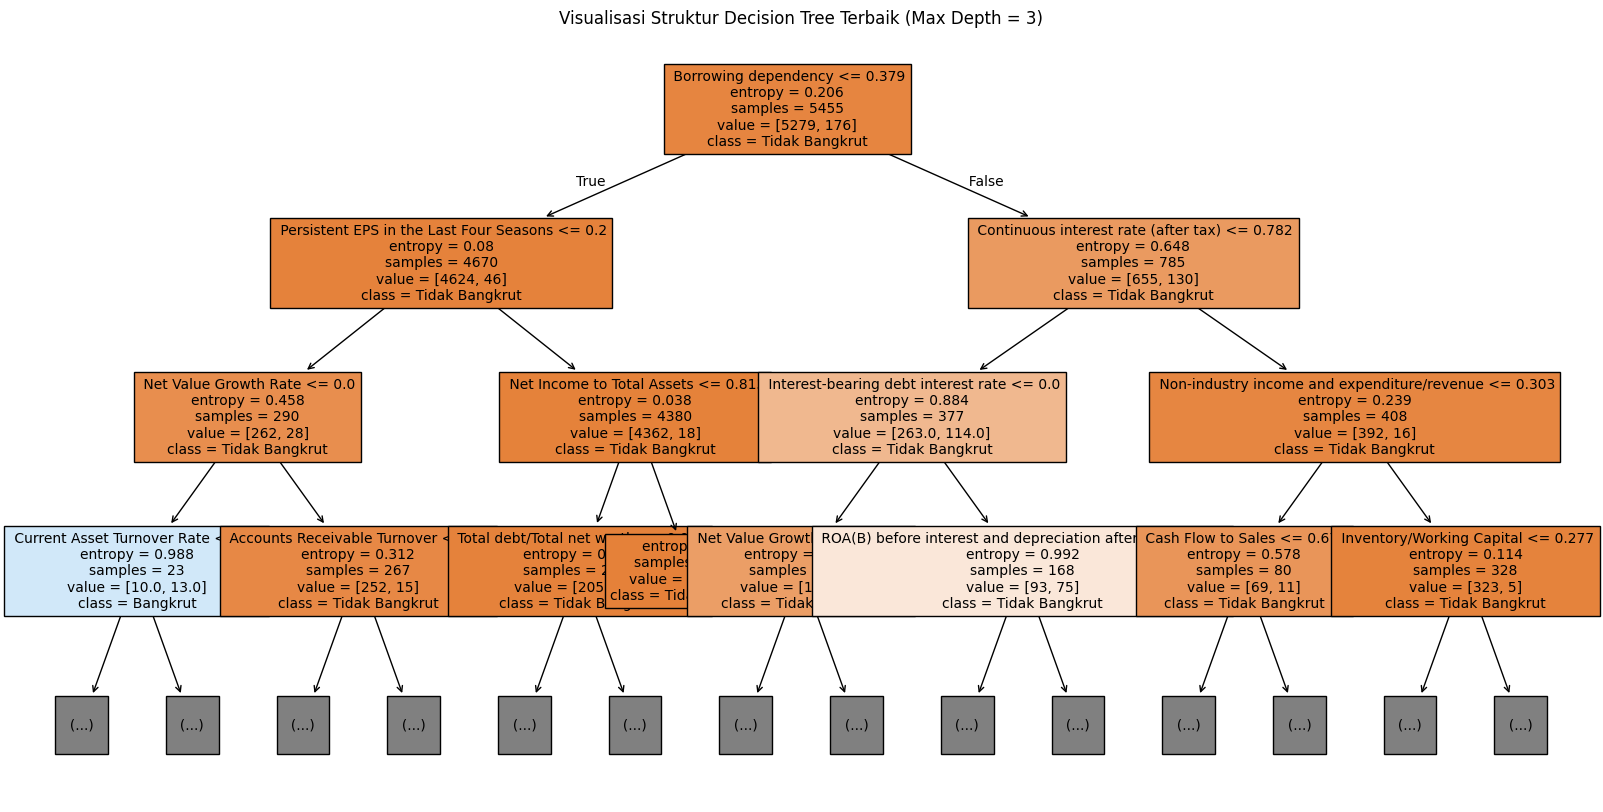

In [53]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
best_model = dt_entropy
plt.figure(figsize=(20, 10))
plot_tree(best_model, 
          feature_names=X.columns, 
          class_names=['Tidak Bangkrut', 'Bangkrut'], 
          filled=True, 
          max_depth=3, 
          fontsize=10)
plt.title("Visualisasi Struktur Decision Tree Terbaik (Max Depth = 3)")
plt.show()

C:\Users\M S I\AppData\Local\Temp\ipykernel_22696\3646156582.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_importance, x='Importance', y='Feature', palette='viridis')


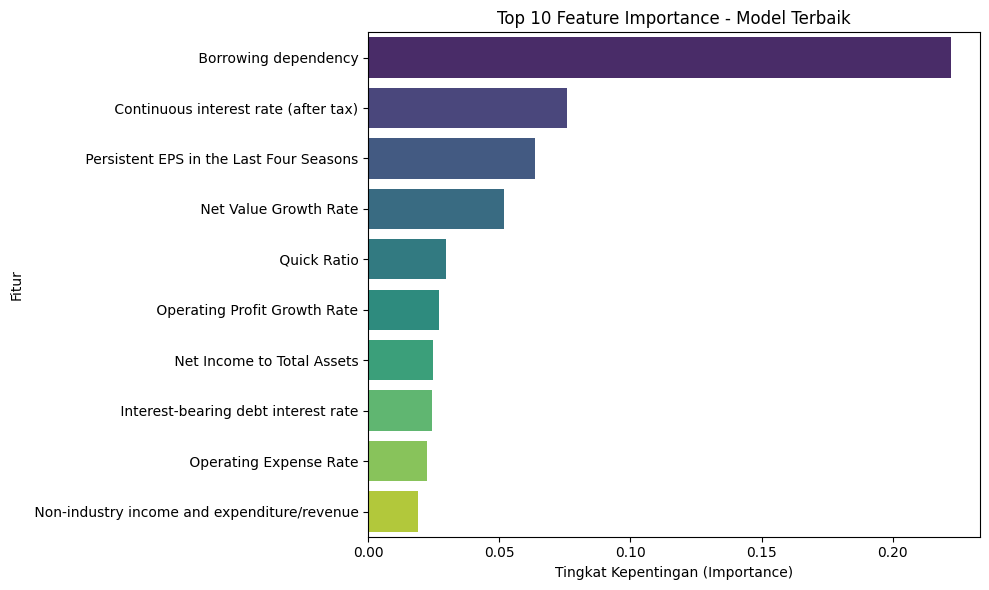

In [54]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = best_model.feature_importances_
# Memasukkannya ke dalam DataFrame untuk diurutkan
df_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)
# Mengambil 10 fitur paling berpengaruh agar grafik tidak terlalu padat
top_10_importance = df_importance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance - Model Terbaik')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
==> Perbedaan tidak terlalu signifikan, yang terlihat berbeda hanya pada Gini terdapat salah menebak 1 kali sedangkan entropy tidak sama sekali

- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
==> Pada nilai 5 model sudah menunjukkan gejala overfitting, terlihat dari grafik training yang pada nilai 5 mulai lebih tinggi cukup tinggi dari hasil test kemudian grafik hasil training dilanjutkan terus naik ke atas.

- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?
==> Borrowing dependency

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Pada hasil train kali ini belum bisa terlihat mana metode yang paling bagus karena data masih terlalu inbalance, sehingga langkah selanjutnya yang terbaik adalah membuat data balance terlebih dahulu. Untuk model sendiri bisa memilih model yang lebih cocok dalam kasus medis serta mementingkan hasil dari recall.